In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

Carga de las librerías necesarias y del dataset resultante de `01_eda.ipynb`, ya limpio (`data/processed/malaga/listings_full_clean.csv`).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(f"{PROJECT_DIR}/data/processed/malaga/listings_full_clean.csv")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,license,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,has_license
0,96033,https://www.airbnb.com/rooms/96033,20260630204216,2026-07-01,city scrape,"Bonito piso a 200m de la playa, El Palo (Málaga)",Do you have a backpacker spirit and are lookin...,https://a0.muscache.com/pictures/hosting/Hosti...,510467,https://www.airbnb.com/users/show/510467,...,4.93,4.47,4.63,Spain - National registration number<br />ESFC...,1,1,0,0,1.97,True
1,166473,https://www.airbnb.com/rooms/166473,20260630204216,2026-07-01,city scrape,Perfect Location In Malaga,This apartment is rented out by the room - new...,https://a0.muscache.com/pictures/miso/Hosting-...,793360,https://www.airbnb.com/users/show/793360,...,4.91,4.81,4.69,Andalucia - Regional registration number<br />...,5,1,4,0,0.59,True
2,330760,https://www.airbnb.com/rooms/330760,20260630204216,2026-07-01,city scrape,Malaga Lodge Guesthouse Double room-shared bath.,The Lodge is set in a charming town house in L...,https://a0.muscache.com/pictures/85419390/38a9...,1687526,https://www.airbnb.com/users/show/1687526,...,4.64,4.65,4.57,Spain - National registration number<br />ESHF...,6,4,2,0,0.55,True
3,340024,https://www.airbnb.com/rooms/340024,20260630204216,2026-07-01,city scrape,NEW APARTMENT IN MALAGA CENTER,Welcome to Málaga!<br />This is a modern and e...,https://a0.muscache.com/pictures/hosting/Hosti...,1725690,https://www.airbnb.com/users/show/1725690,...,4.79,4.75,4.78,Andalucia - Regional registration number<br />...,1,1,0,0,2.27,True
4,358541,https://www.airbnb.com/rooms/358541,20260630204216,2026-07-01,city scrape,Casa La Maga - Apartment for happy people,"For years, Raúl and I were super happy in this...",https://a0.muscache.com/pictures/miso/Hosting-...,1526932,https://www.airbnb.com/users/show/1526932,...,4.97,4.80,4.78,Andalucia - Regional registration number<br />...,1,1,0,0,2.40,True


## 2. Selección de variables de partida

De las 77 columnas del dataset limpio, decidir cuáles se descartan antes de construir features (identificadores, URLs, texto libre sin procesar, columnas redundantes dentro de una misma familia) y cuáles se mantienen como base. Mismo criterio que en Barcelona/Madrid/Valencia.

Se descartan seis grupos de columnas antes de construir ninguna feature:

1. **URLs y metadatos de scraping**: `listing_url`, `picture_url`, `host_url`, `host_profile_url`, `host_picture_url`, `scrape_id`, `last_scraped`, `source`, `calendar_last_scraped`. No describen el alojamiento.
2. **Texto libre sin procesar**: `name`, `description`, `host_about`, `host_location`. `amenities` es distinto: se trata aparte en la sección 9 (flags por palabra clave), no se descarta aquí.
3. **Columnas que ya cumplieron su función**: `bathrooms_text` (ya se extrajo `bathrooms`), `license` (ya existe `has_license`), `host_name` (identificador) y `host_listings_count` (redundante con `calculated_host_listings_count`, recalculado sobre el propio dataset).
4. **`price_quote_*`**: se comprueba a continuación por qué se descartan.
5. **Familias redundantes** detectadas en la EDA: variantes de `minimum_nights`/`maximum_nights`, de `availability`, y las ventanas de reviews más finas (`number_of_reviews_l30d`, `number_of_reviews_ly`).
6. **`estimated_revenue_l365d`**: riesgo de fuga de información, se comprueba también a continuación.

A diferencia de Barcelona/Madrid/Valencia, aquí no hay ningún grupo de "distrito" que descartar en esta fase: Málaga no trae `neighbourhood_group_cleansed` (visto en la EDA), así que la única columna geográfica de partida es `neighbourhood_cleansed`.

#### ¿Por qué se descarta `price_quote_*`?

`price_quote_price_per_night` coincide exactamente con `price` en todas las filas (de hecho, las dos filas artefacto de la EDA sección 8.2 se detectaron justo comprobando esta cotización), y `price_quote_raw` es el JSON de esa misma cotización. No es información nueva.

In [3]:
(df["price"] == df["price_quote_price_per_night"]).mean()

np.float64(1.0)

#### ¿Por qué se descarta `estimated_revenue_l365d`?

Se calcula multiplicando `price` por `estimated_occupancy_l365d`. Usarla como feature sería fuga de información.

In [4]:
(df["price"] * df["estimated_occupancy_l365d"]).corr(df["estimated_revenue_l365d"])

np.float64(0.9999999999686022)

#### ¿Por qué se descartan `name`, `description`, `host_about` y `host_location`?

Texto libre sin estructura: la parte objetiva (tamaño, ubicación, equipamiento) ya está en columnas estructuradas, y sacar señal de texto de verdad requeriría NLP para un beneficio incierto. Se descartan de forma definitiva, igual que en las otras tres ciudades.

#### Aplicando los descartes

In [5]:
drop_cols = [
    # URLs y metadatos de scraping
    "listing_url", "picture_url", "host_url", "host_profile_url", "host_picture_url",
    "scrape_id", "last_scraped", "source", "calendar_last_scraped",
    # texto libre sin procesar (amenities NO va aquí: se procesa en la sección 9)
    "name", "description", "host_about", "host_location",
    # columnas que ya cumplieron su función
    "bathrooms_text", "license", "host_name", "host_listings_count",
    # price_quote_* (redundante con price)
    "price_quote_checkin_date", "price_quote_checkout_date", "price_quote_total_price",
    "price_quote_price_per_night", "price_quote_raw",
    # familias redundantes de estancia
    "minimum_minimum_nights", "maximum_minimum_nights", "minimum_maximum_nights",
    "maximum_maximum_nights", "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
    # familia redundante de disponibilidad
    "availability_30", "availability_60", "availability_90", "availability_eoy",
    # ventanas de reviews más finas
    "number_of_reviews_l30d", "number_of_reviews_ly",
    # fuga de información
    "estimated_revenue_l365d",
]

df = df.drop(columns=drop_cols)
df.shape

(8742, 42)

Quedan 42 columnas de partida: una menos que en las otras tres ciudades, precisamente por no tener `neighbourhood_group_cleansed`. `id`, `host_id` y `host_profile_id` se mantienen como identificadores de referencia. `amenities` se deja para la sección 9. El resto son las que se transforman en las siguientes secciones.

In [6]:
df.columns.tolist()

['id',
 'host_id',
 'host_profile_id',
 'hosts_time_as_user_years',
 'hosts_time_as_user_months',
 'hosts_time_as_host_years',
 'hosts_time_as_host_months',
 'host_is_superhost',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'estimated_occupancy_l365d',
 'first_review',
 'last_review',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'calculated_host_listings_count_shared_rooms',
 'reviews_per_month',
 'has_license']

## 3. Transformaciones numéricas

Logaritmos y ratios sobre las variables numéricas con distribución muy asimétrica y sobre las variables de tamaño.

### 3.1 Logaritmos

En la EDA se midió la asimetría de cada variable numérica. Se aplica `log1p` a las que tienen un coeficiente de asimetría alto: `price` (7.25, ya sin los 2 artefactos de la EDA, pero todavía la más asimétrica con diferencia), `bathrooms` (4.85), `beds` (3.71), `number_of_reviews` (3.22), `calculated_host_listings_count` (2.40), `reviews_per_month` (2.55), `number_of_reviews_ltm` (2.35) y `bedrooms` (2.90). Se guardan como columnas nuevas con sufijo `_log`, sin sustituir a las originales.

In [7]:
log_vars = [
    "price", "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "bedrooms", "beds", "bathrooms", "calculated_host_listings_count",
]

for c in log_vars:
    df[f"{c}_log"] = np.log1p(df[c])

Se comprueba el efecto sobre `price`, la más asimétrica de todas.

Text(0.5, 1.0, 'price_log')

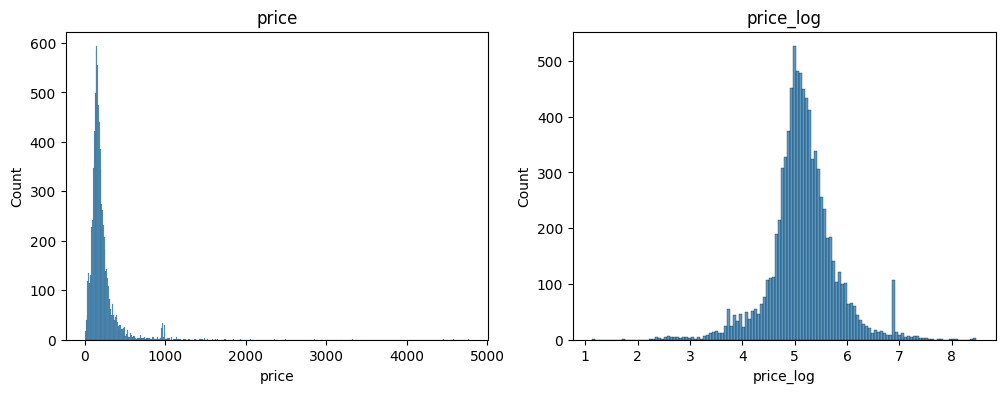

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df, x="price", ax=axes[0])
axes[0].set_title("price")
sns.histplot(df, x="price_log", ax=axes[1])
axes[1].set_title("price_log")

La distribución pasa de una cola larga (todavía marcada por las villas de lujo que quedaron tras la EDA) a una forma mucho más cercana a la normal, igual que en las otras tres ciudades.

### 3.2 Ratios

`price_per_accommodate` normaliza el precio por la capacidad del alojamiento. Se usa `accommodates` como denominador porque nunca vale 0. `price_per_min_night` es el mismo ratio que en las otras ciudades, aplicado aquí.

In [9]:
df["price_per_accommodate"] = df["price"] / df["accommodates"]
df["price_per_min_night"] = df["price"] / df["minimum_nights"]

df[["price_per_accommodate", "price_per_min_night"]].describe()

,price_per_accommodate,price_per_min_night
count,8742.000000,8742.000000
mean,57.515819,160.293274
std,39.701843,187.871960
min,2.100000,0.032308
25%,37.250000,68.000000
50%,49.450000,118.000000
75%,67.000000,191.000000
max,786.666667,4573.500000


<Axes: xlabel='price_per_accommodate', ylabel='Count'>

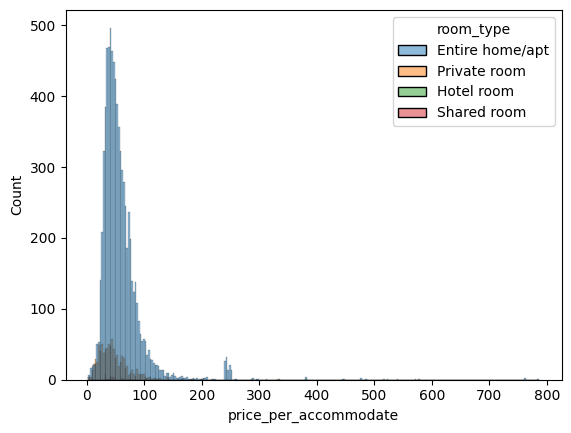

In [10]:
sns.histplot(df, x="price_per_accommodate", hue="room_type")

## 4. Variables de tamaño: multicolinealidad

`accommodates`, `bedrooms`, `beds` y `bathrooms` están correlacionadas entre sí. Decidir si se mantienen todas, se combinan en un índice, o se descarta alguna.

La correlación entre estas cuatro (0.59-0.83) es la más alta de las cuatro ciudades a simple vista, pero eso no basta para decidir. Se calcula el VIF (Variance Inflation Factor): a partir de 5, y sobre todo de 10, se considera multicolinealidad seria.

In [11]:
size_vars = ["accommodates", "bedrooms", "beds", "bathrooms"]

corr_matrix = df[size_vars].corr().values
vif = np.diag(np.linalg.inv(corr_matrix))

pd.Series(vif, index=size_vars, name="VIF")

accommodates    3.828271
bedrooms        3.407374
beds            3.667201
bathrooms       1.868464
Name: VIF, dtype: float64

Los cuatro VIF están entre 1.9 y 3.8, más altos que en Valencia (1.3-2.7) pero todavía lejos del umbral de 5. `bathrooms` vuelve a ser la que menos se solapa con las otras tres (VIF 1.87). Se mantienen las cuatro tal cual, sin combinarlas ni descartar ninguna.

Como en las otras ciudades, esto solo importaría de verdad para un modelo lineal. Si más adelante los coeficientes de estas variables salen inestables entre folds, este es el sitio al que volver.

## 5. Codificación de categóricas

`room_type`, `neighbourhood_cleansed` y `property_type`: agrupar categorías raras donde haga falta y codificar.

### 5.1 `room_type`

4 categorías sin orden natural: one-hot encoding.

In [12]:
df = pd.get_dummies(df, columns=["room_type"], prefix="room_type")

### 5.2 `neighbourhood_cleansed`: distrito y barrio a la vez

Aquí está la decisión que quedó diferida al final de la EDA. En Barcelona/Madrid/Valencia hay dos columnas geográficas con cardinalidad distinta: `neighbourhood_group_cleansed` (el distrito, pocas categorías → one-hot) y `neighbourhood_cleansed` (el barrio, muchas categorías → target encoding). Málaga solo trae una: `neighbourhood_cleansed`, con 11 valores.

Con solo 11 categorías, un one-hot directo es perfectamente manejable: no hace falta agrupar nada ni recurrir a target encoding por cardinalidad. Aun así, se construyen **las dos representaciones a partir de la misma columna**, no solo el one-hot:

- `district_*` (one-hot, 11 columnas): para que el modelo y el resto de la app (que ya asume una familia `district_*` para el desplegable de distrito, el mapa por zonas, etc.) funcionen exactamente igual que en las otras tres ciudades.
- `neighbourhood_price_encoded` (target encoding suavizado, igual que en las otras ciudades): para el desplegable de "barrio" de la app y el resto de la lógica que ya asume esa columna.

Al venir las dos de la misma columna, `neighbourhood_price_encoded` no aporta aquí información estadística que los 11 dummies de `district_*` no tengan ya. A diferencia de Valencia, donde el barrio es más fino que el distrito. Se mantiene igualmente por consistencia con el resto de la app: ni Ridge ni un modelo de árboles tienen problema con una columna redundante, y así el simulador "qué pasaría si cambio de barrio" sigue funcionando sin tocar ese código.

In [13]:
df["district"] = df["neighbourhood_cleansed"]
df = pd.get_dummies(df, columns=["district"], prefix="district")

**Aviso importante**: el target encoding de abajo se calcula con todo el dataset, solo para tener la columna disponible y poder seguir explorando en el resto de este notebook, no es la versión final. Antes de entrenar un modelo de verdad hay que recalcularla usando únicamente los datos de entrenamiento, o se estaría filtrando información del conjunto de test al de entrenamiento. Por eso `neighbourhood_cleansed` (la columna cruda) se mantiene más allá de la limpieza final de la sección 10, en vez de descartarse aquí mismo: la corrección real ocurre en `03_model_baseline.ipynb`, justo después del split.

In [14]:
global_mean_price = df["price"].mean()
neigh_stats = df.groupby("neighbourhood_cleansed")["price"].agg(["mean", "count"])

smoothing = 10
smoothed_mean = (neigh_stats["count"] * neigh_stats["mean"] + smoothing * global_mean_price) / (neigh_stats["count"] + smoothing)

df["neighbourhood_price_encoded"] = df["neighbourhood_cleansed"].map(smoothed_mean)

In [15]:
df[["neighbourhood_cleansed", "neighbourhood_price_encoded"]].drop_duplicates().sort_values("neighbourhood_price_encoded", ascending=False)

,neighbourhood_cleansed,neighbourhood_price_encoded
14,Churriana,373.303144
484,Campanillas,339.389720
0,Este,285.606246
86,Puerto de la Torre,245.315270
348,Palma-Palmilla,213.418786
2,Centro,209.904635
200,Ciudad Jardin,194.841947
28,Carretera de Cadiz,194.200156
44,Teatinos-Universidad,193.803688
29,Cruz de Humilladero,170.256244


`Churriana` encabeza por precio medio (no por mediana: en la EDA, sección 9, `Campanillas` ganaba por mediana), señal de que en `Churriana` la media está más tirada hacia arriba por algunas villas muy caras concretas que en el resto de zonas.

### 5.3 `property_type`

47 categorías, pero muy concentradas: `Entire rental unit` y `Private room in rental unit` son el 79.2% del dataset, y 32 de las 47 categorías tienen menos de 30 anuncios. Igual que en las otras ciudades, aquí sí interesa agrupar en "Otros" antes de codificar: tras agrupar quedan 16 categorías (15 propias + `Other`), un one-hot manejable.

In [16]:
property_type_counts = df["property_type"].value_counts()
rare_property_types = property_type_counts[property_type_counts < 30].index

df["property_type_grouped"] = df["property_type"].where(
    ~df["property_type"].isin(rare_property_types), "Other"
)
df["property_type_grouped"].nunique()

16

In [17]:
df = pd.get_dummies(df, columns=["property_type_grouped"], prefix="property_type")

Con esto, `room_type`, `district` (a partir de `neighbourhood_cleansed`) y `property_type_grouped` quedan como columnas binarias, y `neighbourhood_cleansed` aporta además `neighbourhood_price_encoded` como columna numérica. `property_type` (texto) se descarta en la limpieza final de la sección 10. `neighbourhood_cleansed` (texto) se mantiene hasta después del split en `03_model_baseline.ipynb`, como se explicó en 5.2.

## 6. Variables derivadas del host

Señales sobre el tipo de host a partir de `calculated_host_listings_count`, `host_is_superhost` y la antigüedad.

### 6.1 Antigüedad del host

In [18]:
df["host_tenure_years"] = df["hosts_time_as_host_years"] + df["hosts_time_as_host_months"] / 12
df["host_tenure_years"].describe()

count    8742.000000
mean        6.861426
std         3.776557
min         0.000000
25%         3.500000
50%         7.250000
75%         9.833333
max        15.416667
Name: host_tenure_years, dtype: float64

### 6.2 Tamaño del host

Antes de convertir `calculated_host_listings_count` en un flag binario, se comprueba qué umbral tendría sentido.

In [19]:
for threshold in [1, 2, 5, 10]:
    pct = (df["calculated_host_listings_count"] > threshold).mean() * 100
    print(f"más de {threshold} anuncios: {pct:.1f}%")

más de 1 anuncios: 77.8%
más de 2 anuncios: 67.5%
más de 5 anuncios: 52.6%
más de 10 anuncios: 39.5%


Con `> 1` ya se marca al 77.8% como "profesional" (la mediana de `calculated_host_listings_count` es 6, la más alta de las cuatro ciudades (Málaga es el mercado más dominado por hosts con carteras grandes). Un flag binario no distingue lo suficiente. Se construyen las mismas 4 categorías que en las otras ciudades, por umbrales redondos: `individual` (1 anuncio), `pequeno` (2-10), `mediano` (11-50) y `grande` (51+).

In [20]:
bins = [0, 1, 10, 50, df["calculated_host_listings_count"].max()]
labels = ["individual", "pequeno", "mediano", "grande"]
df["host_size_tier"] = pd.cut(df["calculated_host_listings_count"], bins=bins, labels=labels)

df.groupby("host_size_tier", observed=True)["price"].agg(["count", "median"])

,count,median
host_size_tier,,
individual,1943,168.00
pequeno,3348,155.00
mediano,1807,162.40
grande,1644,217.35


Casi monótona (168.00€ → 155.00€ → 162.40€ → 217.35€), con el mismo bache en `pequeno` que ya aparecía en Valencia. Se prefiere no asumir un orden numérico limpio y se codifica con one-hot.

In [21]:
df = pd.get_dummies(df, columns=["host_size_tier"], prefix="host_size")

### 6.3 Composición del portfolio del host

`calculated_host_listings_count_entire_homes` frente al total del host: qué proporción de los anuncios de ese host son pisos enteros.

In [22]:
df["host_entire_homes_ratio"] = (
    df["calculated_host_listings_count_entire_homes"] / df["calculated_host_listings_count"]
)
df["host_entire_homes_ratio"].corr(df["price"])

np.float64(0.20018581887280118)

0.20 de correlación con `price`, algo mejor que la del propio `calculated_host_listings_count` (0.16), aunque la diferencia es más pequeña que en Valencia (0.27 vs. 0.08). En Málaga, *cuántos* anuncios tiene un host ya aporta algo de señal por sí solo, coherente con que aquí los hosts grandes son mayoría (sección 6.2).

## 7. Variables derivadas de reviews

Señales a partir de `review_scores_rating` y compañía, teniendo en cuenta que una parte de los anuncios no tiene reviews todavía.

### 7.1 `has_reviews`

El 9.0% de los anuncios no tiene reviews todavía. Se deja explícito con un flag.

In [23]:
df["has_reviews"] = df["number_of_reviews"] > 0
df["has_reviews"].value_counts()

has_reviews
True     7955
False     787
Name: count, dtype: int64

### 7.2 Antigüedad y recencia de reviews

Se usa la `last_review` más reciente de todo el dataset como fecha de referencia ('hoy' aproximado).

In [24]:
df["first_review"] = pd.to_datetime(df["first_review"])
df["last_review"] = pd.to_datetime(df["last_review"])

reference_date = df["last_review"].max()
df["listing_age_days"] = (reference_date - df["first_review"]).dt.days
df["days_since_last_review"] = (reference_date - df["last_review"]).dt.days

df[["listing_age_days", "days_since_last_review"]].describe()

,listing_age_days,days_since_last_review
count,7955.000000,7955.000000
mean,1368.231175,156.260465
std,1073.929483,329.396073
min,2.000000,0.000000
25%,534.000000,14.000000
50%,1079.000000,31.000000
75%,1868.000000,134.000000
max,5424.000000,4565.000000


Ambas quedan `NaN` para los anuncios sin reviews, coherente con `has_reviews`. La correlación con `price` es prácticamente nula en las dos (0.01 y 0.06), muy similar a las otras ciudades, pero se mantienen igualmente: son información real que antes estaba encerrada en un texto de fecha.

In [25]:
df["listing_age_days"].corr(df["price"]), df["days_since_last_review"].corr(df["price"])

(np.float64(0.010236993089847), np.float64(0.05923305767647724))

### 7.3 Los 6 subscores de review

Correlacionan entre 0.57 y 0.88 con `review_scores_rating`, y tienen prácticamente los mismos nulos. Misma redundancia que ya se resolvió con las familias de la sección 2: se conserva `review_scores_rating` como resumen y se descartan los 6 subscores.

In [26]:
df = df.drop(columns=[
    "review_scores_accuracy", "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location", "review_scores_value",
])

`review_scores_rating` se deja como `NaN` para los anuncios sin reviews, sin imputar: en la EDA apenas correlaciona con `price` (~0.10-0.12), inventar un valor no aportaría nada.

## 8. Variables geográficas

Alguna codificación adicional de `latitude`/`longitude` más allá del barrio.

### 8.1 Distancia al centro

`neighbourhood_price_encoded` (sección 5) es discreta: dos anuncios muy cerca pero a cada lado de la frontera de un barrio tendrían valores distintos sin motivo real. La distancia en línea recta al centro (Plaza de la Constitución, el casco histórico) da una versión continua del mismo patrón espacial.

In [27]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

center_lat, center_lon = 36.7213, -4.4214  # Plaza de la Constitucion
df["distance_to_center_km"] = haversine(df["latitude"], df["longitude"], center_lat, center_lon)

df["distance_to_center_km"].describe()

count    8742.000000
mean        1.575077
std         1.990338
min         0.002896
25%         0.413463
50%         0.815721
75%         1.756126
max        18.956334
Name: distance_to_center_km, dtype: float64

In [28]:
df["distance_to_center_km"].corr(df["price"]), df["distance_to_center_km"].corr(df["neighbourhood_price_encoded"])

(np.float64(0.12509414844417427), np.float64(0.6246148789645266))

**El patrón contrario al esperado**: la correlación con `price` es positiva (0.13, frente a valores negativos o nulos en las otras tres ciudades) y con `neighbourhood_price_encoded` es fuerte (0.62). Tiene una explicación directa vista en la EDA (secciones 9 y 11): las zonas más caras de Málaga no son el centro, son las villas rurales de `Churriana` y `Campanillas`, en las afueras. Cuanto más lejos del centro, más probable que el anuncio sea una de esas villas grandes: justo lo contrario del patrón habitual "más cerca del centro, más caro" de una ciudad como Barcelona. `distance_to_center_km` se mantiene, como complemento (no sustituto) de `neighbourhood_price_encoded`.

Text(0, 0.5, 'log1p(price)')

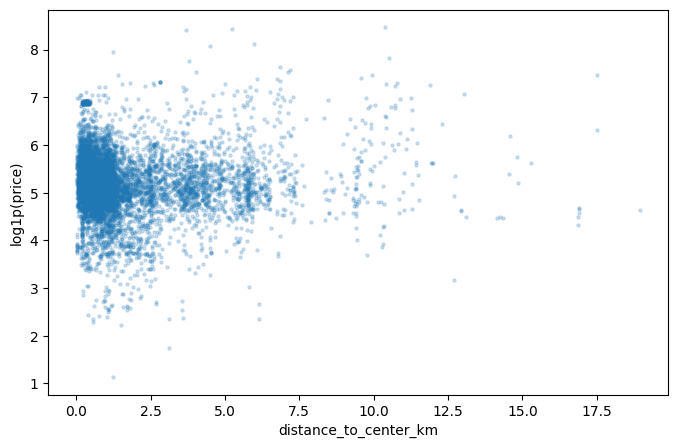

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(df["distance_to_center_km"], np.log1p(df["price"]), s=5, alpha=0.2)
plt.xlabel("distance_to_center_km")
plt.ylabel("log1p(price)")

La nube de puntos confirma la lectura: hay una ligera tendencia creciente (no decreciente), muy distinta a la de una ciudad con un único centro caro.

### 8.2 Densidad de anuncios cercanos

Motivado en la sección 11.5 de la EDA: cuántos otros anuncios reales hay en un radio de 150 metros de cada uno.

In [30]:
from sklearn.neighbors import BallTree

coords_rad = np.radians(df[["latitude", "longitude"]].to_numpy())
tree = BallTree(coords_rad, metric="haversine")
EARTH_R_KM = 6371
radius_m = 150
counts = tree.query_radius(coords_rad, r=(radius_m / 1000) / EARTH_R_KM, count_only=True)
df["n_nearby_150m"] = counts - 1  # excluir el propio anuncio

df["n_nearby_150m"].describe()

count    8742.000000
mean      162.377717
std       153.482888
min         0.000000
25%        34.000000
50%       101.000000
75%       302.000000
max       533.000000
Name: n_nearby_150m, dtype: float64

Mismo resultado que en la EDA (media ~162, mediana 101, números altos porque `Centro` concentra dos tercios del dataset en poca superficie): correlación prácticamente nula con `price` (0.01). A diferencia de `distance_to_center_km`, esta variable no aporta aquí la señal que sí aportaba en Barcelona/Valencia, coherente con que la zona más densa (`Centro`) no es la más cara. Se mantiene por consistencia entre las cuatro ciudades.

## 9. Amenities

Se construyen las cuatro variables motivadas en la sección 12 de la EDA: `has_ac`, `has_pool` y `has_dishwasher` (flags por palabra clave) y `n_amenities` (recuento total). Un one-hot directo de las más de 2000 categorías de `amenities` no es viable (más de la mitad son variantes que aparecen una sola vez).

### 9.1 Parsear y construir los flags

In [31]:
import ast

amenities_parsed = df["amenities"].apply(ast.literal_eval)

def has_any(lst, keywords, exclude=None):
    for item in lst:
        low = item.lower()
        if exclude and any(ex in low for ex in exclude):
            continue
        if any(kw in low for kw in keywords):
            return True
    return False

df["has_ac"] = amenities_parsed.apply(lambda l: has_any(l, ["air condition"]))
df["has_pool"] = amenities_parsed.apply(lambda l: has_any(l, ["pool"], exclude=["pool table"]))
df["has_dishwasher"] = amenities_parsed.apply(lambda l: has_any(l, ["dishwasher"]))
df["n_amenities"] = amenities_parsed.apply(len)

df[["has_ac", "has_pool", "has_dishwasher", "n_amenities"]].describe()

,n_amenities
count,8742.000000
mean,33.751773
std,13.778559
min,0.000000
25%,25.000000
50%,34.000000
75%,43.000000
max,95.000000


Prevalencias consistentes con la EDA (`has_ac` ~78%, `has_dishwasher` ~32%, `has_pool` ~9%, `n_amenities` media ~34). `has_pool` sigue siendo la más prometedora con diferencia: en la EDA correlacionaba **0.229** con `price`, la más alta de las cuatro ciudades pese a ser la de menor prevalencia (8.8%): una piscina es un factor de lujo muy diferenciador en un mercado donde las villas de las afueras marcan los precios más altos (sección 8.1).

### 9.2 Descartar `amenities`

Ya cumplió su función: se descarta el texto crudo.

In [32]:
df = df.drop(columns=["amenities"])
df.shape

(8742, 91)

## 10. Dataset final para modelado

Selección de las columnas finales y guardado en `data/processed/malaga/` para los notebooks de modelado.

### 10.1 Un último cabo suelto: `hosts_time_as_user_*`

En la sección 6 se combinó la antigüedad como host, pero se quedó sin tocar la antigüedad como usuario de Airbnb en general. Se combina igual, por coherencia.

In [33]:
df["host_user_tenure_years"] = df["hosts_time_as_user_years"] + df["hosts_time_as_user_months"] / 12

### 10.2 Limpieza final

Se descartan las columnas ya sustituidas por una versión mejor: `property_type` en texto, las cuatro columnas de antigüedad ya combinadas, `first_review`/`last_review` en formato fecha, y el desglose `calculated_host_listings_count_entire_homes`/`_private_rooms`/`_shared_rooms` (ya resumido en `host_entire_homes_ratio`).

`neighbourhood_cleansed` es la excepción, no se descarta aquí: se mantiene para que `03_model_baseline.ipynb` recalcule `neighbourhood_price_encoded` solo con train justo después del split.

In [34]:
final_drop = [
    "property_type",
    "hosts_time_as_host_years", "hosts_time_as_host_months",
    "hosts_time_as_user_years", "hosts_time_as_user_months",
    "first_review", "last_review",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
]

df = df.drop(columns=final_drop)
df.shape

(8742, 82)

### 10.3 Comprobación de nulos

Debería quedar solo lo que se dejó así a propósito: todo lo relacionado con anuncios sin reviews todavía.

In [35]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0]

review_scores_rating      787
listing_age_days          787
days_since_last_review    787
dtype: int64

Las tres coinciden exactamente en las mismas 787 filas (`has_reviews == False`), tal y como se esperaba. No hace falta ninguna acción más.

### 10.4 Identificadores, objetivo y features

`id`, `host_id` y `host_profile_id` son referencias, no entran como input del modelo. `price` es la variable objetivo. `neighbourhood_cleansed` viaja en el CSV pero todavía no es una feature (pendiente de la corrección de fuga en `03_model_baseline.ipynb`). El resto son las features.

In [36]:
id_cols = ["id", "host_id", "host_profile_id"]
target_col = "price"
pending_cols = ["neighbourhood_cleansed"]
feature_cols = [c for c in df.columns if c not in id_cols + [target_col] + pending_cols]

print("identificadores:", len(id_cols))
print("objetivo:", target_col)
print("pendiente de la corrección de fuga (03_model_baseline.ipynb):", len(pending_cols))
print("features:", len(feature_cols))

identificadores: 3
objetivo: price
pendiente de la corrección de fuga (03_model_baseline.ipynb): 1
features: 77


82 columnas en total: 3 identificadores, 1 objetivo, 1 pendiente y **77 features**. Un número algo más bajo que Valencia (84): con solo 11 distritos (frente a 19) y sin nivel de barrio adicional que codificar aparte, `district_*` aporta menos columnas, aunque `neighbourhood_price_encoded` viva aquí, como se explicó en 5.2, sobre la misma partición que el distrito.

### 10.5 Exportar

In [37]:
df.to_csv(f"{PROJECT_DIR}/data/processed/malaga/listings_full_features.csv", index=False)